In [1]:
import numpy as np
import pandas as pd
from sympy import rotations


In [2]:
df = pd.read_csv('rigel_customer_interviews_realistic_1248.csv')

In [5]:
df['current_workflow'].value_counts()

current_workflow
Spreadsheet + checklist + meeting notes              217
Intake package + spreadsheets + narrative memo       157
Spreadsheets + templates + legacy tool               143
Spreadsheets + checklists + templates                123
Spreadsheet + CRM notes + PDF exports                107
Checklist + legacy planning tool + screenshots       100
Spreadsheet + email threads + Word memo               97
Regional process variations + manual review           88
Manual validation + institutional knowledge           80
Manual estate flow map rebuilt for each case          46
Spreadsheet + external reporting pack                 46
Legacy operations system + offline reconciliation     44
Name: count, dtype: int64

In [4]:
df['recommended_product_focus'].value_counts() ##30


recommended_product_focus
Strengthen versioning, assumptions tracking, and appendix logic. Invest in permissions, logging, and governance controls. Improve export fidelity for client, compliance, and leadership audiences.                                                                                                                               159
Prioritize fast-path intake and answer-screen workflow. Strengthen versioning, assumptions tracking, and appendix logic. Improve export fidelity for client, compliance, and leadership audiences.                                                                                                                                123
Prioritize fast-path intake and answer-screen workflow. Improve export fidelity for client, compliance, and leadership audiences.                                                                                                                                                                                                 

In [7]:
df['primary_pain_point'].value_counts()

primary_pain_point
Manual estate reviews are slow and inconsistent                        75
Bypass vs through-estate confusion creates advisor risk                74
Outputs are hard to defend during compliance review                    71
Beneficiary details are messy, incomplete, or scattered                68
Current tools feel like a CRM instead of a decision tool               68
Straightforward cases still take too long to prepare                   68
Workarounds hide risk in free-text notes                               61
Reporting must withstand scrutiny from leadership and community        57
Specialist bottlenecks slow case resolution                            53
Analysts rebuild the same maps repeatedly                              51
Manual work leads to audit findings or near-misses                     49
Complex ownership structures are hard to trace                         49
Distribution outcomes remain unclear until late in the file            49
Governance expectat

In [3]:
new = df[["customer_type","interaction_stage", "decision_role","current_workflow","primary_pain_point","secondary_pain_points","must_haves","nice_to_haves","deal_breakers","buying_triggers","edge_case_observed","modules_discussed","workflow_blockers","sentiment","recommended_product_focus","theme_tags"]]
new.head(5)

,customer_type,interaction_stage,decision_role,current_workflow,primary_pain_point,secondary_pain_points,must_haves,nice_to_haves,deal_breakers,buying_triggers,edge_case_observed,modules_discussed,workflow_blockers,sentiment,recommended_product_focus,theme_tags
0,Advisor,Pilot evaluation,Influencer,Spreadsheet + checklist + meeting notes,"Beneficiary details are messy, incomplete, or ...",Current tools feel like a CRM instead of a dec...,Meeting-ready answer screen; One-click PDF/CSV...,Pre-filled templates; Lightweight document vault,Fragile UX,Rising compliance pressure,Multiple registered accounts with inconsistent...,Roles and permissions; Exports; Versioning; In...,Manual re-entry of data; Export formatting cle...,Mixed / cautious,"Improve export fidelity for client, compliance...",Estate flow clarity; Export quality
1,Advisor,Workflow review,Evaluator,Spreadsheet + checklist + meeting notes,Outputs are hard to defend during compliance r...,Straightforward cases still take too long to p...,Household intake in under 10 minutes; Meeting-...,Optional guided intake prompts; Pre-filled tem...,CRM-like complexity,Backlog of estate review work; Need to standar...,Joint property mixed with individually held as...,Scenario compare; Exports; Answer screen; Vers...,Need for clearer estate flow classification; S...,Mixed / cautious,"Strengthen versioning, assumptions tracking, a...",Estate flow clarity; Export quality; Scenario ...
2,Advisor,Pilot evaluation,Decision-maker,Checklist + legacy planning tool + screenshots,Bypass vs through-estate confusion creates adv...,Straightforward cases still take too long to p...,Scenario comparisons that reuse existing data;...,Lightweight document vault,CRM-like complexity; Black-box logic,Team wants faster pre-meeting preparation; Ris...,Second marriage with adult children from prior...,Exports; Audit trail; Intake; Answer screen,Scattered data across spreadsheets and notes; ...,Mixed / cautious,"Invest in permissions, logging, and governance...",Auditability; Estate flow clarity; Export qual...
3,Advisor,Workflow review,Decision-maker,Spreadsheet + checklist + meeting notes,Manual estate reviews are slow and inconsistent,Straightforward cases still take too long to p...,Scenario comparisons that reuse existing data;...,Polished visuals if explainable,CRM-like complexity; Workflow slower than Exce...,Backlog of estate review work; Rising complian...,Second marriage with adult children from prior...,Roles and permissions; Versioning; Audit trail...,Scattered data across spreadsheets and notes; ...,Mixed / cautious,Prioritize fast-path intake and answer-screen ...,Estate flow clarity; Export quality; Scenario ...
4,Advisor,Prototype feedback,Decision-maker,Spreadsheet + CRM notes + PDF exports,Current tools feel like a CRM instead of a dec...,Bypass vs through-estate confusion creates adv...,Scenario comparisons that reuse existing data;...,Pre-filled templates,Black-box logic,Need to standardize outputs across a branch,Second marriage with adult children from prior...,Beneficiary mapping; Scenario compare; Intake;...,Scattered data across spreadsheets and notes,Negative on current workflow,Prioritize fast-path intake and answer-screen ...,Export quality; Scenario modelling; Speed


In [ ]:
new.describe()

In [7]:
# Isolate the 11 rows where recommended_product_focus is null
null_rows = new[new['recommended_product_focus'].isnull()]

# Check if these 11 rows share a specific sentiment or buyer type
print(null_rows['sentiment'].value_counts(dropna=False))
print(null_rows['customer_type'].value_counts(dropna=False))


sentiment
Negative on current workflow                4
Mixed / cautious                            3
Positive on concept, cautious on rollout    3
Strongly positive                           1
Name: count, dtype: int64
customer_type
Advisor           6
Estate Planner    5
Name: count, dtype: int64


In [8]:
# Group by BOTH factors and look at the most frequent product focus
relationship_matrix = new.groupby(['customer_type', 'decision_role'], dropna=False)['recommended_product_focus'].value_counts(normalize=True).unstack(fill_value=0)

print(relationship_matrix)


recommended_product_focus                    Improve export fidelity for client, compliance, and leadership audiences.  \
customer_type                decision_role                                                                               
Advisor                      Decision-maker                                           0.096154                           
                             End user                                                 0.041667                           
                             Evaluator                                                0.076087                           
                             Influencer                                               0.116438                           
Enterprise                   Decision-maker                                           0.028846                           
                             End user                                                 0.000000                           
                        

In [17]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    # Create a clean contingency table dropping nulls just for this calculation
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Correct for bias
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Run the test for both variables against the target
print("Customer Type Strength:", cramers_v(new['customer_type'], new['recommended_product_focus']))
print("Decision Role Strength:", cramers_v(new['decision_role'], new['recommended_product_focus']))


Customer Type Strength: 0.6657530340710965
Decision Role Strength: 0.0


In [15]:
new_product = new[["recommended_product_focus","current_workflow"]].copy()

product_series = (
    new_product["recommended_product_focus"]
    .str.split(".")
    .explode()
    .str.strip()
)
product_series = product_series[product_series != ""]
print(product_series.value_counts())

recommended_product_focus
Improve export fidelity for client, compliance, and leadership audiences    1038
Strengthen versioning, assumptions tracking, and appendix logic              713
Prioritize fast-path intake and answer-screen workflow                       574
Invest in permissions, logging, and governance controls                      568
Treat Section 87 as a first-class workflow, not an exception path            318
Name: count, dtype: int64


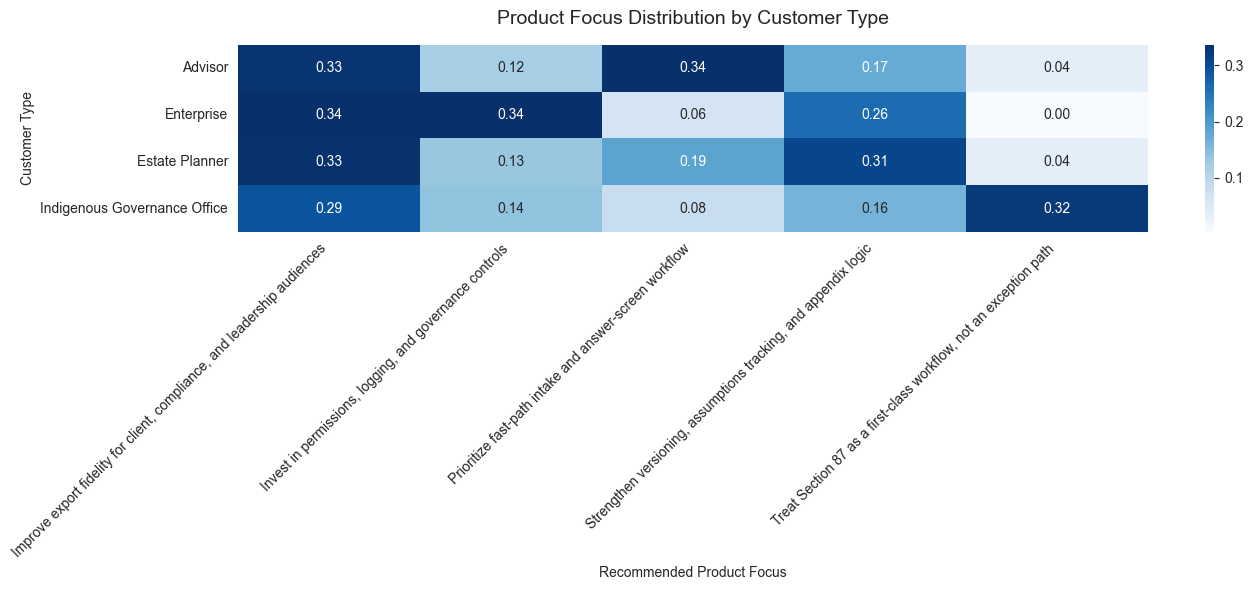

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df_product_analysis = new.copy()
df_product_analysis['product_list'] = df_product_analysis['recommended_product_focus'].str.split('.', regex=False)
df_product_analysis = df_product_analysis.explode('product_list')
df_product_analysis['product_list'] = df_product_analysis['product_list'].str.strip()
df_product_analysis = df_product_analysis[df_product_analysis['product_list'] != ""]


product_cross = pd.crosstab(
    df_product_analysis['customer_type'],
    df_product_analysis['product_list'],
    normalize='index'
)
plt.figure(figsize=(14, 6))
sns.heatmap(
    product_cross,
    annot=True,
    cmap='Blues',
    fmt='.2f'
)
plt.title('Product Focus Distribution by Customer Type', fontsize=14, pad=15)
plt.xlabel('Recommended Product Focus')
plt.ylabel('Customer Type')


plt.xticks(rotation=45, ha='right')
plt.tight_layout() #
plt.savefig('Customer_product.png', dpi=300, bbox_inches='tight')
plt.show()


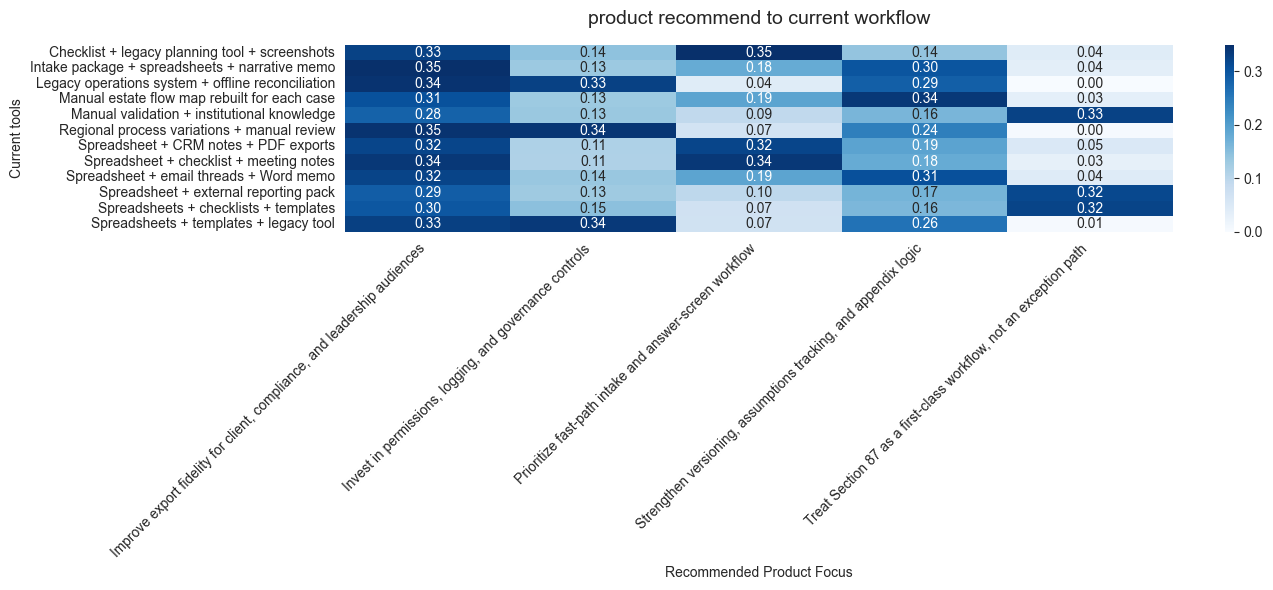

In [6]:
df_product_analysis = new.copy()
df_product_analysis['product_list'] = df_product_analysis['recommended_product_focus'].str.split('.', regex=False)
df_product_analysis = df_product_analysis.explode('product_list')
df_product_analysis['product_list'] = df_product_analysis['product_list'].str.strip()
df_product_analysis = df_product_analysis[df_product_analysis['product_list'] != ""]
product_cross = pd.crosstab(
    df_product_analysis['current_workflow'],
    df_product_analysis['product_list'],
    normalize='index'
)

plt.figure(figsize=(14, 6))
sns.heatmap(
    product_cross,
    annot=True,
    cmap='Blues',
    fmt='.2f'
)
plt.title('product recommend to current workflow', fontsize=14, pad=15)
plt.xlabel('Recommended Product Focus')
plt.ylabel('Current tools')

plt.xticks(rotation=45, ha='right')
plt.tight_layout() #
plt.savefig('recommend_workflow.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# 1. Clean up spacing, split by semicolon, and explode into individual rows
exploded_deal_breakers = new['deal_breakers'].str.split(';').explode().str.strip()

# 2. Run value_counts on the clean, individual entries
print(exploded_deal_breakers.value_counts(dropna=False))


deal_breakers
CRM-like complexity                                            146
Workflow slower than Excel for simple cases                    135
Notes-only logic                                               124
Messy or incomplete exports                                    120
Black-box logic                                                119
Fragile UX                                                     113
Anything that cannot show its work                             111
Hidden logic                                                   108
Outputs that are not reproducible                              107
Forced workarounds outside structured inputs                   102
Generic workflows that ignore governance context                99
Outputs that cannot be audited end-to-end                       93
Workaround notes instead of structured inputs                   91
Weak governance                                                 89
Treating Indigenous trust administration as an a

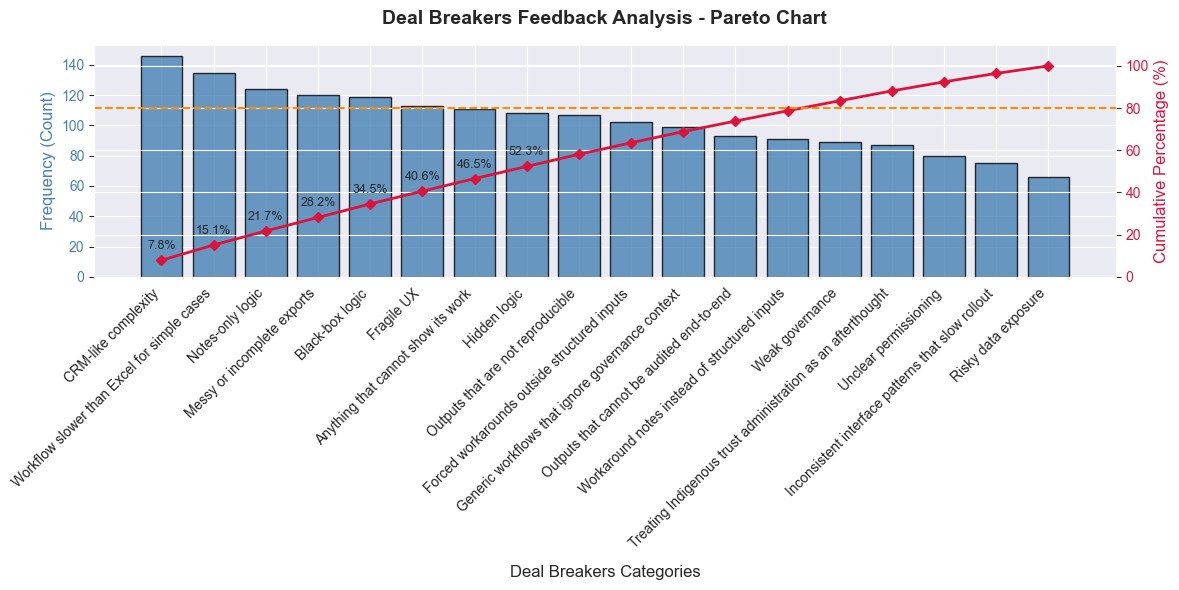

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
# 1. Get frequencies and convert to DataFrame
counts = exploded_deal_breakers.value_counts(dropna=False)
df_pareto = pd.DataFrame({'counts': counts})

# 2. Calculate cumulative percentage
df_pareto['cumpercentage'] = df_pareto['counts'].cumsum() / df_pareto['counts'].sum() * 100

# 3. Create canvas and primary axis (Left axis: Frequency Bars)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot bars
ax1.bar(df_pareto.index, df_pareto['counts'], color='steelblue', alpha=0.8, edgecolor='black')
ax1.set_xlabel('Deal Breakers Categories', fontsize=12, labelpad=10)
ax1.set_ylabel('Frequency (Count)', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Rotate labels for better readability
ax1.set_xticks(range(len(df_pareto)))
ax1.set_xticklabels(df_pareto.index, rotation=45, ha='right')

# 4. Create secondary axis (Right axis: Cumulative Percentage Line)
ax2 = ax1.twinx()
ax2.plot(df_pareto.index, df_pareto['cumpercentage'], color='crimson', marker='D', ms=5, linewidth=2)
ax2.set_ylabel('Cumulative Percentage (%)', fontsize=12, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.set_ylim(0, 110)

# 5. Add the 80% Pareto threshold line
ax2.axhline(80, color='darkorange', linestyle='--', linewidth=1.5, label='80% Threshold')

# 6. Annotate values on the line (only for the top 8 to prevent overlap)
for i, pct in enumerate(df_pareto['cumpercentage']):
    if i < 8:
        ax2.annotate(f"{pct:.1f}%", (i, pct), textcoords="offset points", xytext=(0,8), ha='center', fontsize=9)

# 7. Chart formatting
plt.title('Deal Breakers Feedback Analysis - Pareto Chart', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()


In [9]:
import pandas as pd

# 1. 定义映射字典（保持不变）
category_map = {
    'Spreadsheet + checklist + meeting notes': 'Spreadsheet-workflow',
    'Spreadsheet + CRM notes + PDF exports': 'Spreadsheet-workflow',
    'Spreadsheet + email threads + Word memo': 'Spreadsheet-workflow',
    'Spreadsheet + external reporting pack': 'Spreadsheet-workflow',
    'Spreadsheets + checklists + templates': 'Spreadsheet-workflow',
    'Intake package + spreadsheets + narrative memo': 'Intake & template',
    'Spreadsheets + templates + legacy tool': 'Intake & template',
    'Checklist + legacy planning tool + screenshots': 'Legacy-workflows',
    'Checklist + legacy planning tool + screenshots ': 'Legacy-workflows',
    'Legacy operations system + offline reconciliation': 'Legacy-workflows',
    'Regional process variations + manual review': 'Manual & institution-dependent',
    'Manual validation + institutional knowledge ': 'Manual & institution-dependent',
    'Manual estate flow map rebuilt for each case': 'Manual & institution-dependent'
}


workflow_pain = new[['current_workflow', 'primary_pain_point']].copy().reset_index(drop=True)
workflow_pain ['mapped_workflow'] = workflow_pain ['current_workflow'].str.strip().replace(category_map)


workflow_pain ['primary_pain_point'] = workflow_pain ['primary_pain_point'].str.strip()

workflow_pain  = workflow_pain [workflow_pain ['primary_pain_point'].str.len() > 0]

final_crosstable = pd.crosstab(
    index=workflow_pain ['mapped_workflow'],
    columns=workflow_pain ['primary_pain_point'],
    normalize='index'
)

print((final_crosstable * 100).round(1).astype(str) + '%')



primary_pain_point                          Activity logs and access changes are hard to reconstruct  \
mapped_workflow                                                                                        
Intake & template                                                                         8.0%         
Legacy-workflows                                                                          4.9%         
Manual & institution-dependent                                                           11.2%         
Manual validation + institutional knowledge                                               0.0%         
Spreadsheet-workflow                                                                      0.0%         

primary_pain_point                          Analysts rebuild the same maps repeatedly  \
mapped_workflow                                                                         
Intake & template                                                                7.3%   
Lega

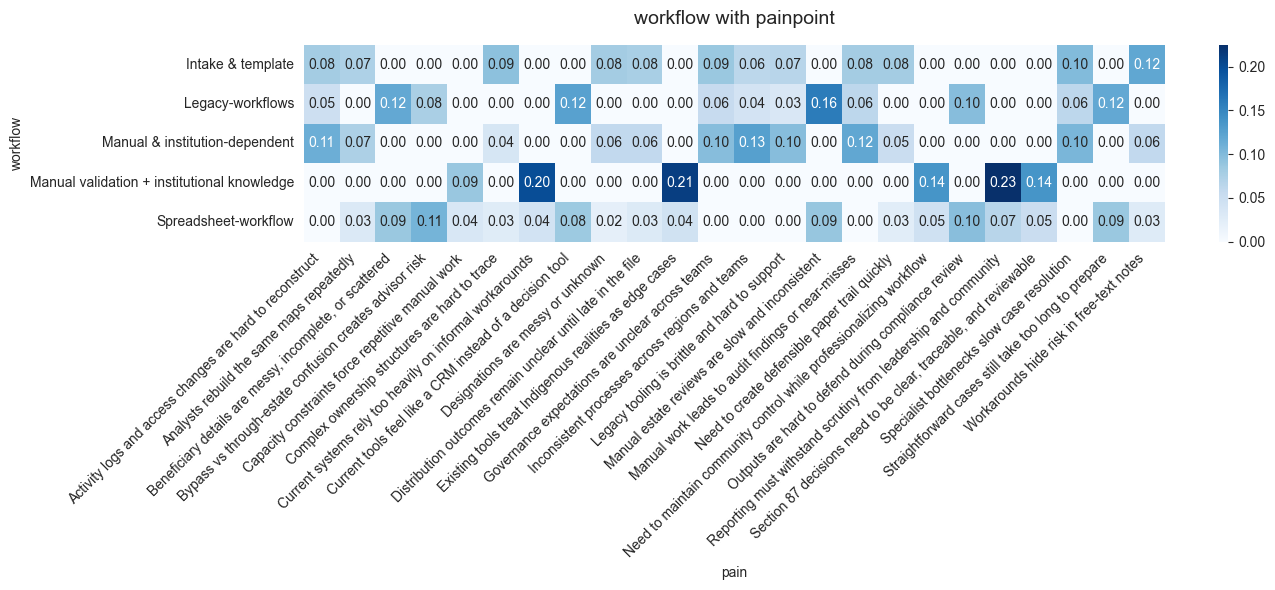

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(14, 6))
sns.heatmap(
    final_crosstable,
    annot=True,
    cmap='Blues',
    fmt='.2f'
)
plt.title('workflow with painpoint', fontsize=14, pad=15)
plt.xlabel('pain')
plt.ylabel('workflow')
plt.xticks(rotation=45, ha='right')
plt.tight_layout() #
plt.savefig('workflow_pain.png', dpi=300, bbox_inches='tight')
plt.show()


In [22]:
import pandas as pd


category_map = {
    'Spreadsheet + checklist + meeting notes': 'Spreadsheet-workflow',
    'Spreadsheet + CRM notes + PDF exports': 'Spreadsheet-workflow',
    'Spreadsheet + email threads + Word memo': 'Spreadsheet-workflow',
    'Spreadsheet + external reporting pack': 'Spreadsheet-workflow',
    'Spreadsheets + checklists + templates': 'Spreadsheet-workflow',
    'Intake package + spreadsheets + narrative memo': 'Intake & template',
    'Spreadsheets + templates + legacy tool': 'Intake & template',
    'Checklist + legacy planning tool + screenshots': 'Legacy-workflows',
    'Checklist + legacy planning tool + screenshots ': 'Legacy-workflows',
    'Legacy operations system + offline reconciliation': 'Legacy-workflows',
    'Regional process variations + manual review': 'Manual & institution-dependent',
    'Manual validation + institutional knowledge ': 'Manual & institution-dependent',
    'Manual estate flow map rebuilt for each case': 'Manual & institution-dependent'
}

workflow_breaker = new[['current_workflow', 'deal_breakers']].copy().reset_index(drop=True)
workflow_breaker['mapped_workflow'] = workflow_breaker['current_workflow'].str.strip().replace(category_map)


workflow_breaker['deal_breakers'] = workflow_breaker['deal_breakers'].str.split(';')

workflow_breaker = workflow_breaker.explode('deal_breakers')

workflow_breaker['single_breaker'] = workflow_breaker['deal_breakers'].str.strip()

workflow_breaker = workflow_breaker[workflow_breaker['single_breaker'].str.len() > 0]

final_crosstable = pd.crosstab(
    index=workflow_breaker['mapped_workflow'],
    columns=workflow_breaker['single_breaker'],
    normalize='index'
)

print((final_crosstable * 100).round(1).astype(str) + '%')



single_breaker                              Anything that cannot show its work  \
mapped_workflow                                                                  
Intake & template                                                        12.8%   
Legacy-workflows                                                          0.0%   
Manual & institution-dependent                                            7.4%   
Manual validation + institutional knowledge                               0.0%   
Spreadsheet-workflow                                                      4.4%   

single_breaker                              Black-box logic  \
mapped_workflow                                               
Intake & template                                      0.0%   
Legacy-workflows                                      13.0%   
Manual & institution-dependent                         0.0%   
Manual validation + institutional knowledge            0.0%   
Spreadsheet-workflow                           

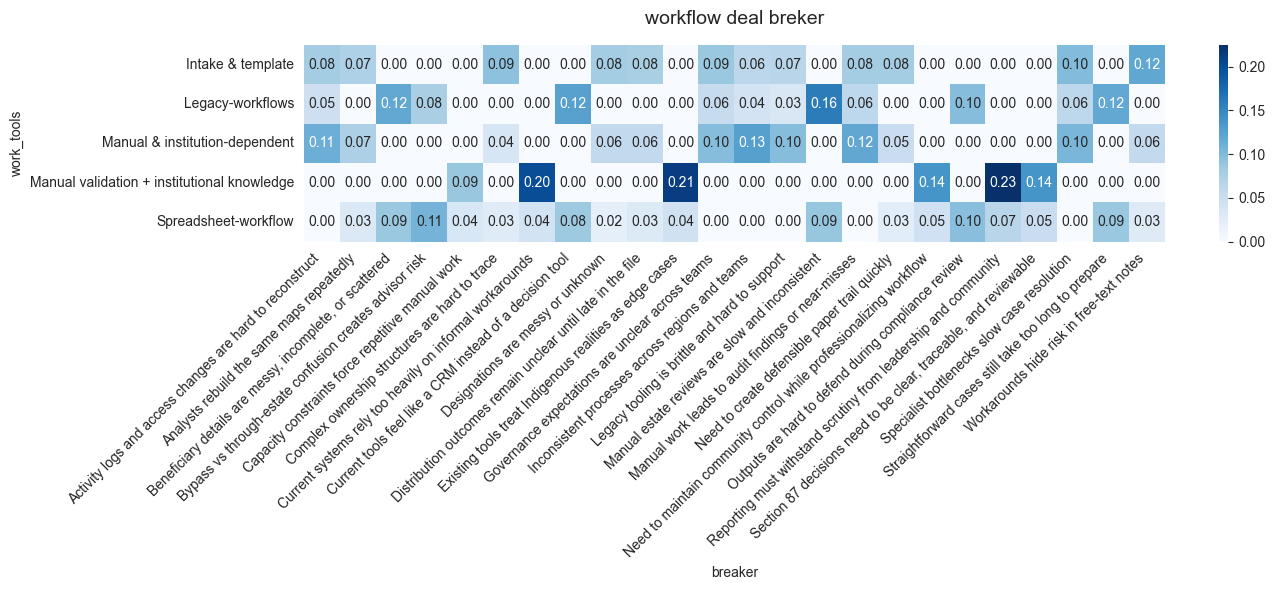

In [11]:
plt.figure(figsize=(14, 6))
sns.heatmap(
    final_crosstable,
    annot=True,
    cmap='Blues',
    fmt='.2f'
)
plt.title('workflow deal breker', fontsize=14, pad=15)
plt.xlabel('breaker')
plt.ylabel('work_tools')
plt.xticks(rotation=45, ha='right')
plt.tight_layout() #
plt.savefig('workflow_breaker.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
pain_counts = new['primary_pain_point'].value_counts().reset_index()
pain_counts.columns = ['pain_point', 'count']
pain_counts["cumulative_percentage"] = pain_counts["count"].cumsum() / pain_counts["count"].sum()
core_pain_points = pain_counts[pain_counts['cumulative_percentage'] <= 0.85]['pain_point'].tolist()

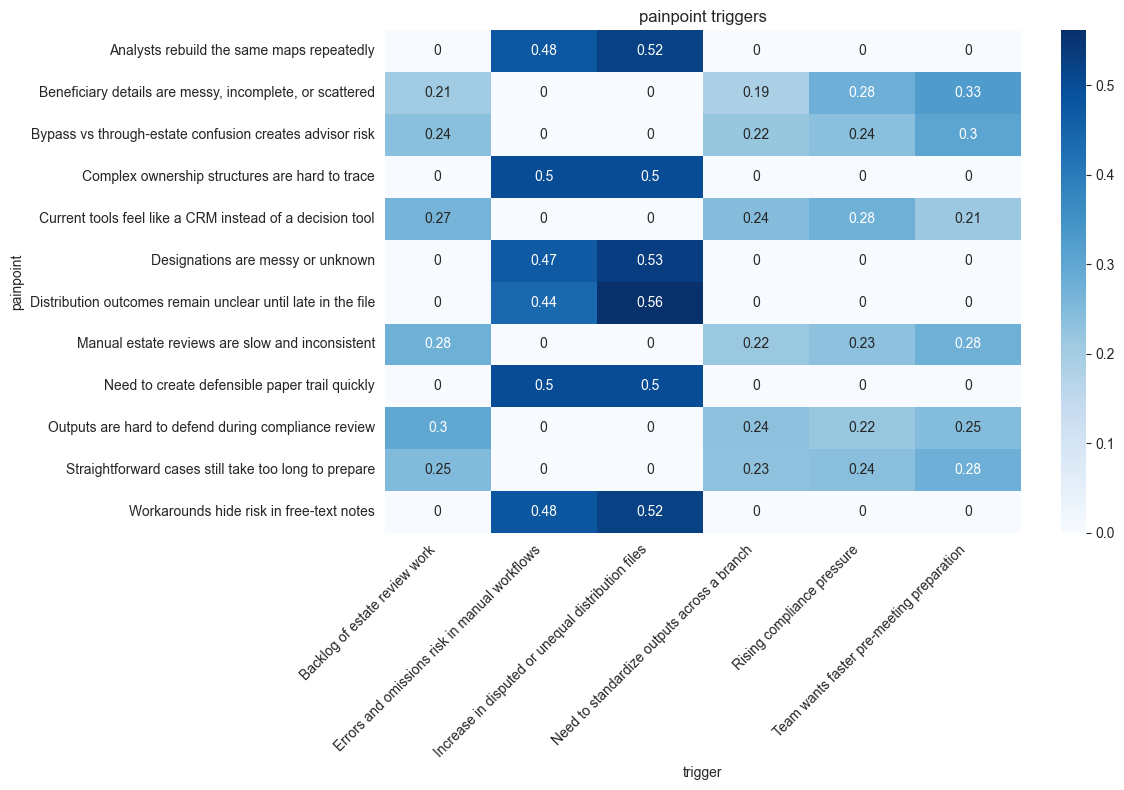

In [13]:
filtered_df = new[new['primary_pain_point'].isin(core_pain_points)].copy().reset_index(drop=True)
filtered_df['buying_triggers'] = filtered_df['buying_triggers'].str.split(';')

filtered_df = filtered_df.explode('buying_triggers')

filtered_df['single_trigger'] = filtered_df['buying_triggers'].str.strip()

filtered_df = filtered_df[filtered_df['single_trigger'].str.len() > 0]
trigger_count = (
    filtered_df['single_trigger']
    .value_counts()
)
top_trigger = trigger_count.head(6).index

filtered_df = filtered_df[
    filtered_df['single_trigger'].isin(top_trigger)
]
matrics =pd.crosstab(
   index=filtered_df['primary_pain_point'],
    columns=filtered_df['single_trigger'],
    normalize='index'
)
plt.figure(figsize=(12, 8))
sns.heatmap(
    matrics,
    annot=True,
    cmap='Blues',
)
plt.title('painpoint triggers')
plt.xlabel('trigger')
plt.ylabel('painpoint')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('pain_triggers.png', dpi=300, bbox_inches='tight')
plt.show()

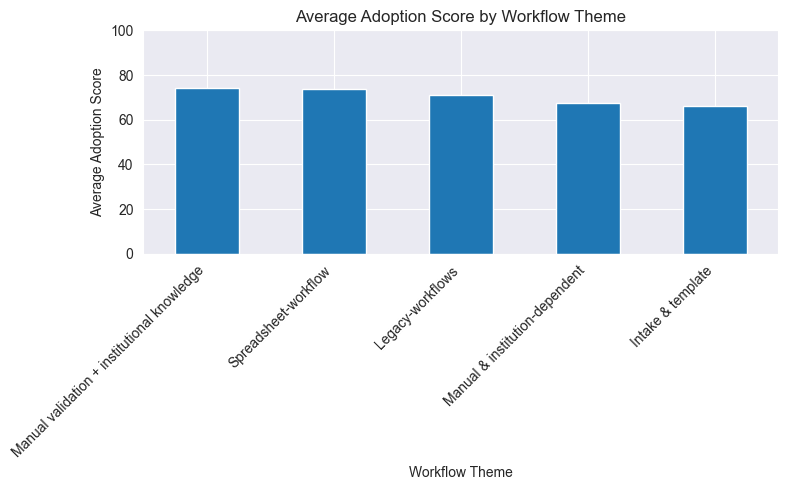

In [34]:
df['workflow_theme'] = (
    df['current_workflow']
    .replace(category_map)
)
workflow_adoption = (
    df.groupby('workflow_theme')['adoption_score_100']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

workflow_adoption.plot(
    kind='bar'
)

plt.title('Average Adoption Score by Workflow Theme')
plt.ylabel('Average Adoption Score')
plt.xlabel('Workflow Theme')

plt.xticks(rotation=45, ha='right')
plt.ylim(0,100)   # adoption score from 0-100

plt.tight_layout()
plt.show()

In [6]:
category_map = {
    'Spreadsheet + checklist + meeting notes': 'Spreadsheet-workflow',
    'Spreadsheet + CRM notes + PDF exports': 'Spreadsheet-workflow',
    'Spreadsheet + email threads + Word memo': 'Spreadsheet-workflow',
    'Spreadsheet + external reporting pack': 'Spreadsheet-workflow',
    'Spreadsheets + checklists + templates': 'Spreadsheet-workflow',
    'Intake package + spreadsheets + narrative memo': 'Intake & template',
    'Spreadsheets + templates + legacy tool': 'Intake & template',
    'Checklist + legacy planning tool + screenshots': 'Legacy-workflows',
    'Checklist + legacy planning tool + screenshots ': 'Legacy-workflows',
    'Legacy operations system + offline reconciliation': 'Legacy-workflows',
    'Regional process variations + manual review': 'Manual & institution-dependent',
    'Manual validation + institutional knowledge ': 'Manual & institution-dependent',
    'Manual estate flow map rebuilt for each case': 'Manual & institution-dependent'
}


df['workflow_theme'] = df['current_workflow'].replace(category_map)
df["blockers_list"] = (
    df["workflow_blockers"]
      .str.strip(";")
      .str.split(";")
)
blockers_list = df.explode("blockers_list")
blockers_list["blockers_list"] = (
    blockers_list["blockers_list"]
      .str.strip()
)
result = pd.crosstab(
    blockers_list['workflow_theme'],
    blockers_list['blockers_list'],
    normalize='index'
)
result

blockers_list,Beneficiary designations not current,Compliance review pressure,Export formatting cleanup,Low tolerance for onboarding friction,Manual re-entry of data,Need for clearer estate flow classification,Permissions and governance concerns,Scattered data across spreadsheets and notes,Section 87 applicability uncertainty,Time pressure in live meetings
workflow_theme,,,,,,,,,,
Intake & template,0.079447,0.100173,0.084629,0.101900,0.101900,0.110535,0.120898,0.098446,0.113990,0.088083
Legacy-workflows,0.088435,0.102041,0.105442,0.102041,0.112245,0.091837,0.091837,0.074830,0.108844,0.122449
Manual & institution-dependent,0.094203,0.105072,0.123188,0.123188,0.119565,0.072464,0.097826,0.086957,0.072464,0.105072
Manual validation + institutional knowledge,0.083333,0.102564,0.102564,0.083333,0.096154,0.102564,0.102564,0.083333,0.141026,0.102564
Spreadsheet-workflow,0.101667,0.091667,0.104167,0.088333,0.089167,0.120833,0.095000,0.102500,0.113333,0.093333


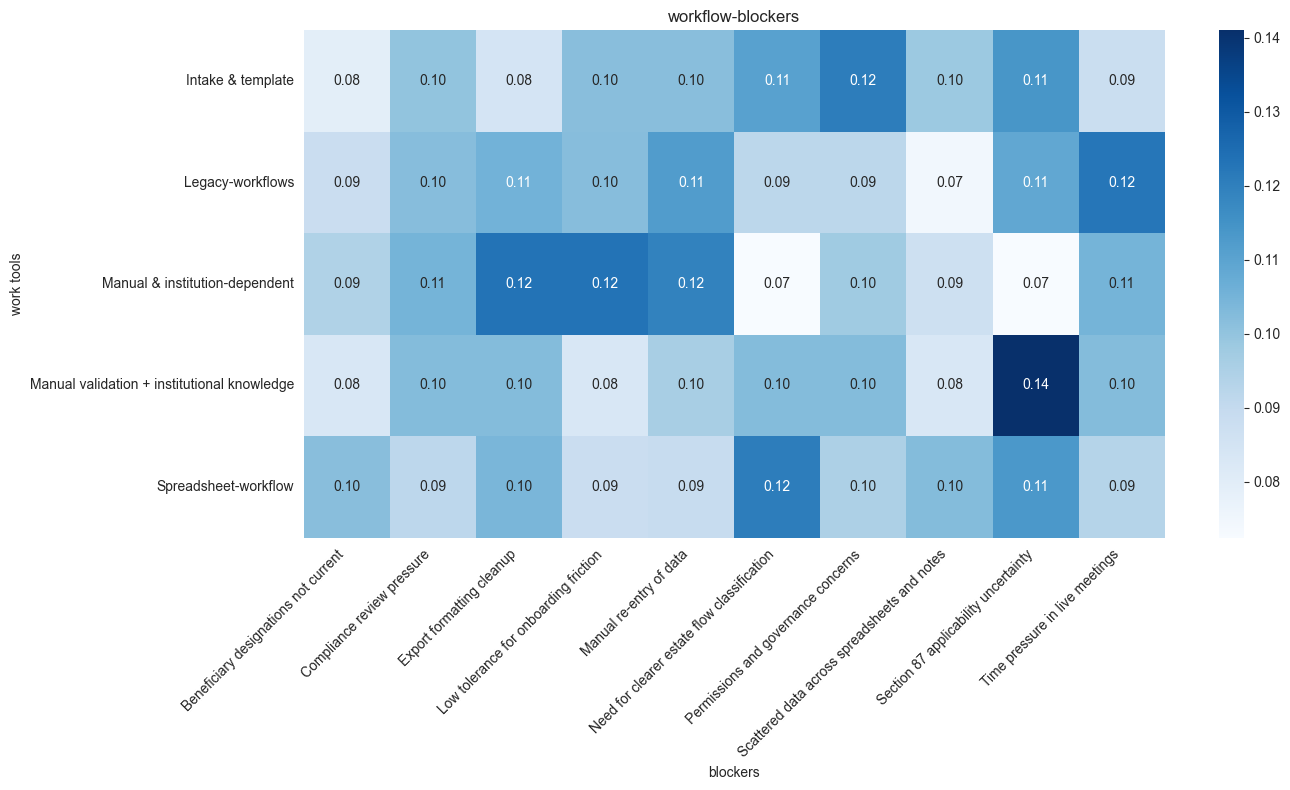

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(14,8))
sns.heatmap(
    result,
    annot=True,
    cmap='Blues',
    fmt='.2f'
)
plt.title('workflow-blockers')
plt.xlabel('blockers')
plt.ylabel('work tools')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()



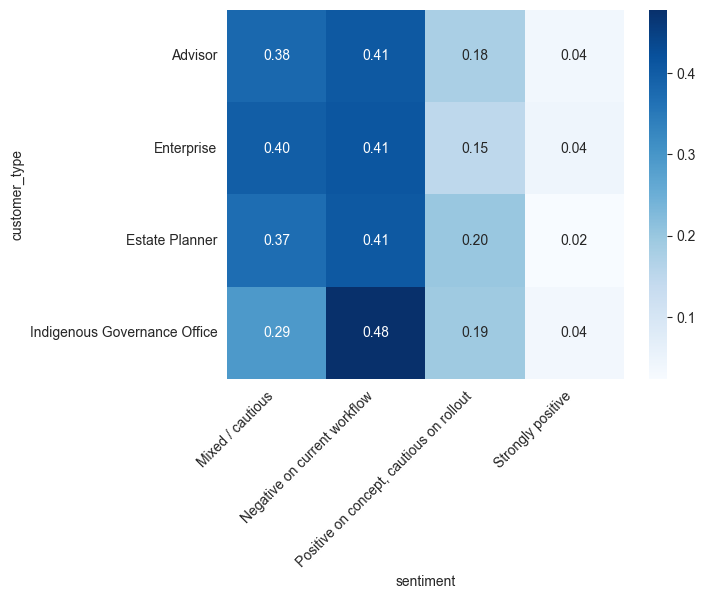

In [27]:
senti= pd.crosstab(
    df['customer_type'],
    df['sentiment'],
    normalize='index'
)

sns.heatmap(
    senti,
    annot=True,
    cmap='Blues',
    fmt='.2f'
)
plt.xticks(rotation=45, ha='right')
plt.show()

In [5]:
df_product_customer = new.copy()

df_product_customer['product_list'] = (
    df_product_customer['recommended_product_focus']
    .str.split('.', regex=False)
)

df_product_customer = df_product_customer.explode('product_list')

df_product_customer['product_list'] = (
    df_product_customer['product_list']
    .str.strip()
)

df_product_customer = (
    df_product_customer[
        df_product_customer['product_list'] != ''
    ]
)

df_product_customer[
[
'customer_type',
'product_list'
]
].to_csv(
    'customer_product_focus.csv',
    index=False
)

In [7]:
df_workflow_product = new.copy()

df_workflow_product['product_list'] = (
    df_workflow_product['recommended_product_focus']
    .str.split('.', regex=False)
)

df_workflow_product = df_workflow_product.explode(
    'product_list'
)

df_workflow_product['product_list'] = (
    df_workflow_product['product_list']
    .str.strip()
)

df_workflow_product = (
    df_workflow_product[
        df_workflow_product['product_list'] != ''
    ]
)

df_workflow_product[
[
'current_workflow',
'product_list'
]
].to_csv(
    'workflow_product_focus.csv',
    index=False
)

In [8]:
pain_counts = (
    new['primary_pain_point']
    .value_counts()
    .reset_index()
)

pain_counts.columns = [
    'pain_point',
    'count'
]

pain_counts['cumulative_percentage'] = (
    pain_counts['count'].cumsum()
    / pain_counts['count'].sum()
)

core_pain_points = (
    pain_counts[
        pain_counts['cumulative_percentage'] <= 0.85
    ]['pain_point']
    .tolist()
)

filtered_df = (
    new[
        new['primary_pain_point'].isin(core_pain_points)
    ]
    .copy()
)

filtered_df['buying_triggers'] = (
    filtered_df['buying_triggers']
    .str.split(';')
)

filtered_df = filtered_df.explode(
    'buying_triggers'
)

filtered_df['single_trigger'] = (
    filtered_df['buying_triggers']
    .str.strip()
)

filtered_df = (
    filtered_df[
        filtered_df['single_trigger'].str.len() > 0
    ]
)

trigger_count = (
    filtered_df['single_trigger']
    .value_counts()
)

top_trigger = (
    trigger_count.head(6).index
)

filtered_df = (
    filtered_df[
        filtered_df['single_trigger'].isin(top_trigger)
    ]
)

filtered_df[
[
'primary_pain_point',
'single_trigger'
]
].to_csv(
    'painpoint_trigger.csv',
    index=False
)